# Stage 2 — Asset Allocation Regression (Experiment Notebook)

An interactive, visual companion to `src/train_models.py`, focused **only** on the second stage of the pipeline: predicting **how much equity and how much bond** an investor's portfolio should hold.

This notebook is designed to:

- **Showcase** the full multi-output regression workflow end-to-end
- **Let you switch the evaluation metric** with a single variable (`EVAL_METRIC`) and see how the winner changes
- **Let you experiment** with hyperparameters and re-run
- Compare five different regressors on the same data

Nothing is written to disk — the production training script (`src/train_models.py`) owns saved models and reports.

## 1. What this regressor predicts

Given an investor's 19 features (same features as Stage 1), the model predicts **two continuous targets simultaneously**:

| Target | Range | Meaning |
|---|---|---|
| `equity_pct` | 0.0 – 1.0 | Fraction of portfolio in stock ETFs |
| `bond_pct`   | 0.0 – 1.0 | Fraction of portfolio in bond ETFs |

The third bucket (`alt_pct`, alternatives) is **not** predicted here — it is computed at inference time as `max(0.01, 1 - equity_pct - bond_pct)` so the three allocations sum to 1. Only two targets are learned.

This is **Stage 2** of a 4-stage pipeline:

1. Risk profile classification (Stage 1, see `phase3A_classification_experiments.ipynb`)
2. **(this notebook)** Asset allocation regression — equity % and bond %
3. Total ETF count regression
4. Rule-based ETF ticker selection

**Naive baseline:** always predict the training mean (e.g., `equity_pct ≈ 0.55`, `bond_pct ≈ 0.30`). Any useful model should beat that comfortably.

## 2. Setup

In [27]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error,
                             mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

DATA_DIR = '../data/training'
print('Libraries imported.')

Libraries imported.


## 3. Experiment Controls

**This is the only cell you usually need to touch.** Change a value here and re-run all cells below.

| Variable | What it controls |
|---|---|
| `EVAL_METRIC` | The metric used to (a) drive Grid Search and (b) rank models on the test set. One of `'mae'`, `'mape'`, `'rmse'`, `'r2'`. |
| `CV_FOLDS` | Number of cross-validation folds inside Grid Search. Higher = more reliable but slower. |
| `RANDOM_STATE` | Seed for reproducibility — same seed = same results. |
| `RUN_GRID_SEARCH` | If `False`, models are fit with default hyperparameters (much faster, no tuning). |
| `PARAM_GRIDS` | The hyperparameter values searched per model. Note the `estimator__` prefix for multi-output wrappers. |

### Metric cheat-sheet

| `EVAL_METRIC` | Lower is better? | Sensitive to | Notes |
|---|---|---|---|
| `'mae'`  | yes | outliers (linearly) | average absolute error in same units as target (a fraction here) |
| `'mape'` | yes | small-true-value samples | average **percentage** error — unstable when `bond_pct ≈ 0` |
| `'rmse'` | yes | outliers (quadratically) | penalises big errors more than small ones |
| `'r2'`   | **no** — higher is better | overall variance explained | 1.0 = perfect, 0.0 = no better than predicting the mean |

In [28]:
# ===== EDIT ME =====
EVAL_METRIC     = 'mae'   # try 'mape', 'rmse', 'r2' and re-run
CV_FOLDS        = 5
RANDOM_STATE    = 42
RUN_GRID_SEARCH = True

# Map our friendly metric name → the sklearn scorer Grid Search uses, and
# whether "lower is better" when ranking the final test-set results.
METRIC_TO_SKLEARN_SCORER = {
    'mae':  'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2':   'r2',
}
LOWER_IS_BETTER = {'mae': True, 'mape': True, 'rmse': True, 'r2': False}

# Small grids — fast enough for repeated runs during a demo.
# The 'estimator__' prefix is required for MultiOutputRegressor wrappers.
# (Linear & Ridge support multi-output natively, no prefix needed.)
PARAM_GRIDS = {
    'Linear Regression': {
        # No real hyperparameters to tune — included as a baseline.
    },
    'Ridge': {
        'alpha': [0.1, 1.0, 10.0, 100.0],   # L2 regularisation strength
    },
    'Random Forest': {
        'estimator__n_estimators':      [100, 200, 500],
        'estimator__max_depth':         [10, 15, None],
        'estimator__min_samples_split': [5, 10],
    },
    'Gradient Boosting': {
        'estimator__n_estimators':  [100, 200, 500],
        'estimator__max_depth':     [3, 5],
        'estimator__learning_rate': [0.05, 0.1],
    },
    'XGBoost': {
        'estimator__n_estimators':  [100, 200, 500],
        'estimator__max_depth':     [4, 6],
        'estimator__learning_rate': [0.05, 0.1],
    },
}

assert EVAL_METRIC in METRIC_TO_SKLEARN_SCORER, \
    f'EVAL_METRIC must be one of {list(METRIC_TO_SKLEARN_SCORER)}'

print(f'Evaluation metric:  {EVAL_METRIC}  (lower is better: {LOWER_IS_BETTER[EVAL_METRIC]})')
print(f'CV folds:           {CV_FOLDS}')
print(f'Random state:       {RANDOM_STATE}')
print(f'Run grid search:    {RUN_GRID_SEARCH}')


Evaluation metric:  mae  (lower is better: True)
CV folds:           5
Random state:       42
Run grid search:    True


## 4. Load the prepared training data

The features (`X`) and labels (`y2_*`) come from `phase2_data_preparation.ipynb` using the same 80/20 stratified split as Stage 1. Results in this notebook are directly comparable to `src/train_models.py`.

In [29]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')

y_train = pd.read_csv(f'{DATA_DIR}/y_train_allocation.csv')   # columns: equity_pct, bond_pct
y_test  = pd.read_csv(f'{DATA_DIR}/y_test_allocation.csv')

TARGETS = ['equity_pct', 'bond_pct']

print(f'Train: {X_train.shape[0]:>5} rows  |  Test: {X_test.shape[0]:>5} rows')
print(f'Features: {X_train.shape[1]}   Targets: {TARGETS}')
y_train.head()

Train:  4000 rows  |  Test:  1000 rows
Features: 19   Targets: ['equity_pct', 'bond_pct']


,equity_pct,bond_pct
0,0.7314,0.1834
1,0.7645,0.1309
2,0.3758,0.5298
3,0.5287,0.3630
4,0.5808,0.3114


## 5. Understanding the targets

Before any modelling, look at the targets. Two things to check:

1. **What is the spread?** A target that varies a lot is easier to evaluate — if everyone's `equity_pct` were 0.5, predicting 0.5 would be "perfect" without learning anything.
2. **Are there small values?** If `bond_pct` is near 0 for many investors, **MAPE** (mean **percentage** error) will explode because we divide by tiny true values. That's why MAE is usually safer here.

In [30]:
stats = pd.concat([y_train.describe().T.add_prefix('train_'),
                   y_test.describe().T.add_prefix('test_')], axis=1)
stats

,train_count,train_mean,train_std,train_min,train_25%,train_50%,train_75%,train_max,test_count,test_mean,test_std,test_min,test_25%,test_50%,test_75%,test_max
equity_pct,4000.0000,0.5643,0.1833,0.2096,0.3795,0.5481,0.7629,0.9235,1000.0000,0.5655,0.1817,0.1942,0.3835,0.5490,0.7667,0.9008
bond_pct,4000.0000,0.3360,0.1836,0.0098,0.1383,0.3530,0.5205,0.6889,1000.0000,0.3344,0.1819,0.0099,0.1357,0.3509,0.5178,0.7040


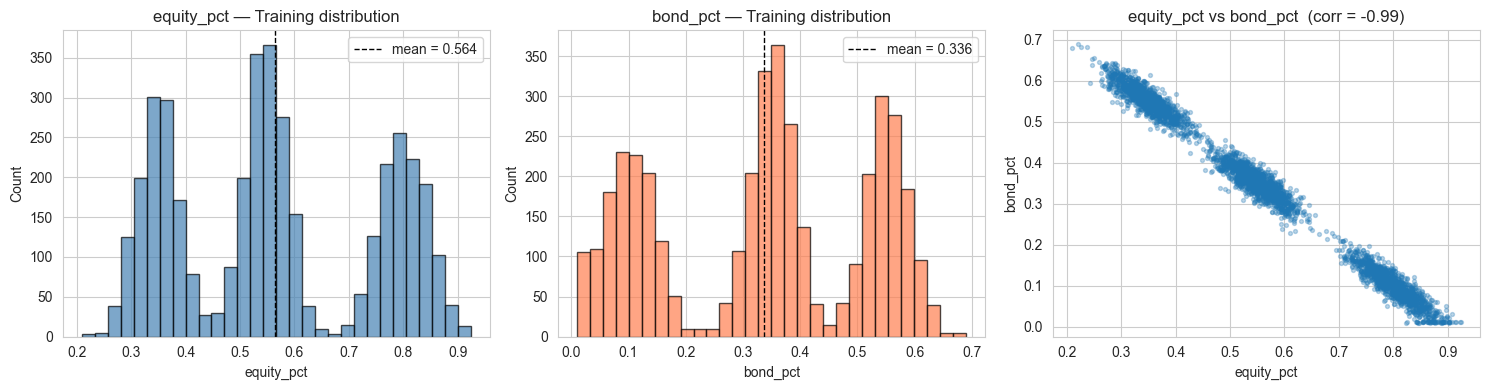

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Two histograms — one per target.
for ax, col, color in zip(axes[:2], TARGETS, ['steelblue', 'coral']):
    ax.hist(y_train[col], bins=30, alpha=0.7, color=color, edgecolor='black')
    ax.set_title(f'{col} — Training distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.axvline(y_train[col].mean(), ls='--', color='black', lw=1,
               label=f'mean = {y_train[col].mean():.3f}')
    ax.legend()

# Scatter: how much do equity and bond move together?
# Strong negative correlation (~ -1) would mean knowing one tells you the other.
axes[2].scatter(y_train['equity_pct'], y_train['bond_pct'], alpha=0.3, s=8)
corr = y_train['equity_pct'].corr(y_train['bond_pct'])
axes[2].set_title(f'equity_pct vs bond_pct  (corr = {corr:.2f})')
axes[2].set_xlabel('equity_pct')
axes[2].set_ylabel('bond_pct')

plt.tight_layout()
plt.show()

## 6. The concepts — quick primer

### 6.1 Regression vs Classification

Stage 1 was **classification**: pick a class out of 3. Stage 2 is **regression**: output a continuous number. Different problems, different metrics, different models (although many algorithms have a regressor variant of the classifier you already know).

### 6.2 Multi-output regression

We predict **two numbers at once** (`equity_pct`, `bond_pct`). Two ways to do that:

- **Native multi-output**: some models (LinearRegression, Ridge, RandomForest, MLP) handle multi-target out of the box.
- **`MultiOutputRegressor` wrapper**: trains one independent model per target. We use it here for GradientBoosting and XGBoost, which only handle a single target. Hyperparameter names then need an `estimator__` prefix in the grid (e.g. `estimator__n_estimators`).

### 6.3 Regression metrics — which to pick

| Metric | Formula sketch | Reads as | When to use |
|---|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | average absolute error in **same units** as target | Default choice. Robust. Easy to explain. |
| **MAPE** | mean(\|y - ŷ\| / \|y\|) | average **percentage** error | Good when target is large and strictly positive. **Unstable when `y ≈ 0`** — not ideal here. |
| **RMSE** | sqrt(mean((y - ŷ)²)) | same units as target, but big errors hurt more | Use when large errors are disproportionately bad. |
| **R²** | 1 - SSE/SS_tot | fraction of variance explained, 0 → 1 (can go negative) | Comparing across datasets. 1.0 = perfect, 0.0 = no better than predicting the mean. |

### 6.4 Grid Search + CV (recap)

Same as Stage 1: try every combination of hyperparameters, score each one by K-fold CV on the **training** set, pick the best. The test set stays untouched until final evaluation. See `phase3A_classification_experiments.ipynb` for a longer walkthrough.

### 6.5 How to read a residual plot

Residual = actual − predicted. A *good* residual plot:

- centred around 0 (no systematic over/underprediction)
- evenly spread along the x-axis (no "fan" pattern)
- no curvy trend (no missed non-linearity)

Patterns in the residuals are the model telling you what it's still getting wrong.

## 7. Helpers

One function `evaluate_regressor` does Grid Search (optional), fits, and computes **every** metric — not just the one we're optimising. That way the comparison table later shows you the full picture, not just the chosen metric.

In [32]:
def per_target_metrics(y_true, y_pred):
    """Compute MAE / MAPE / RMSE / R² separately for each target column."""
    out = {}
    for i, col in enumerate(TARGETS):
        yt = y_true[col].values
        yp = y_pred[:, i]
        out[col] = {
            'mae':  mean_absolute_error(yt, yp),
            # MAPE divides by |y_true|. sklearn protects against /0 with an epsilon,
            # but values can still blow up when y_true is small (e.g. bond_pct near 0).
            'mape': mean_absolute_percentage_error(yt, yp),
            'rmse': np.sqrt(mean_squared_error(yt, yp)),
            'r2':   r2_score(yt, yp),
        }
    return out


def aggregate_metric(per_target, metric):
    """Average a single metric across both targets — used for ranking."""
    return np.mean([per_target[t][metric] for t in TARGETS])


def evaluate_regressor(name, estimator, param_grid):
    """Run GridSearchCV (or a plain fit) and return a dict of every metric we care about."""
    n_combos = int(np.prod([len(v) for v in param_grid.values()])) if param_grid else 1
    n_fits   = n_combos * CV_FOLDS

    scorer = METRIC_TO_SKLEARN_SCORER[EVAL_METRIC]

    if RUN_GRID_SEARCH and param_grid:
        gs = GridSearchCV(estimator, param_grid, cv=CV_FOLDS,
                          scoring=scorer, n_jobs=-1)
        gs.fit(X_train, y_train)
        best_model    = gs.best_estimator_
        best_params   = gs.best_params_
        # GridSearchCV maximises its scorer, so 'neg_*' scores come back negative.
        # Flip the sign so the printed CV score is in natural units.
        best_cv_score = gs.best_score_
        if scorer.startswith('neg_'):
            best_cv_score = -best_cv_score
    else:
        estimator.fit(X_train, y_train)
        best_model    = estimator
        best_params   = '(no grid search)'
        best_cv_score = np.nan

    train_pred = best_model.predict(X_train)
    test_pred  = best_model.predict(X_test)

    train_per = per_target_metrics(y_train, train_pred)
    test_per  = per_target_metrics(y_test,  test_pred)

    train_score = aggregate_metric(train_per, EVAL_METRIC)
    test_score  = aggregate_metric(test_per,  EVAL_METRIC)

    print(f'  Grid: {n_combos} combos × {CV_FOLDS} folds = {n_fits} fits')
    print(f'  Best params:        {best_params}')
    if not np.isnan(best_cv_score):
        print(f'  Best CV {EVAL_METRIC:<5}        {best_cv_score:.4f}')
    print(f'  Train {EVAL_METRIC} (avg):    {train_score:.4f}')
    print(f'  Test  {EVAL_METRIC} (avg):    {test_score:.4f}')
    for t in TARGETS:
        print(f'     - {t}: '
              + '  '.join(f'{m}={test_per[t][m]:.4f}' for m in ['mae','mape','rmse','r2']))

    return {
        'name':         name,
        'best_params':  best_params,
        'best_cv':      best_cv_score,
        'train_per':    train_per,
        'test_per':     test_per,
        'train_score':  train_score,
        'test_score':   test_score,
        'test_pred':    test_pred,
        'model':        best_model,
    }


results = {}
print('Helpers ready.')

Helpers ready.


## 8. Train and tune each model

Each model below follows the same pattern:

1. Define the estimator (wrapped in `MultiOutputRegressor` when it doesn't handle multi-target natively)
2. Look up its grid in `PARAM_GRIDS`
3. Hand both to `evaluate_regressor` — it runs Grid Search, computes every metric, and prints a summary

Everything is controlled by the variables in **Experiment Controls** (section 3).

### 8.1 Linear Regression — minimal baseline

Plain ordinary least squares. No hyperparameters worth tuning. If LR already does well, the problem is mostly linear and the fancier models won't add much. LinearRegression supports multi-output natively — no wrapper needed.

In [33]:
print('--- Linear Regression ---')
results['Linear Regression'] = evaluate_regressor(
    'Linear Regression',
    LinearRegression(n_jobs=-1),
    PARAM_GRIDS['Linear Regression'],
)

--- Linear Regression ---
  Grid: 1 combos × 5 folds = 5 fits
  Best params:        (no grid search)
  Train mae (avg):    0.1469
  Test  mae (avg):    0.1479
     - equity_pct: mae=0.1478  mape=0.2984  rmse=0.1762  r2=0.0586
     - bond_pct: mae=0.1481  mape=1.3565  rmse=0.1761  r2=0.0625


### 8.2 Ridge — regularised linear baseline

Linear regression + L2 penalty on coefficients. `alpha` controls how much the penalty pulls coefficients toward zero: `alpha=0` recovers plain LR, very large `alpha` predicts (approximately) the mean. Useful when features are correlated or you want a more conservative fit.

In [34]:
print('--- Ridge ---')
results['Ridge'] = evaluate_regressor(
    'Ridge',
    Ridge(random_state=RANDOM_STATE),
    PARAM_GRIDS['Ridge'],
)

--- Ridge ---
  Grid: 4 combos × 5 folds = 20 fits
  Best params:        {'alpha': 10.0}
  Best CV mae          0.1477
  Train mae (avg):    0.1469
  Test  mae (avg):    0.1479
     - equity_pct: mae=0.1477  mape=0.2984  rmse=0.1762  r2=0.0589
     - bond_pct: mae=0.1481  mape=1.3572  rmse=0.1760  r2=0.0629


### 8.3 Random Forest — bagged decision trees

Many decision trees on bootstrap samples, predictions averaged. Strong default for tabular regression: handles non-linearities, doesn't need feature scaling, gives free **feature importances**. We wrap it in `MultiOutputRegressor` to match the structure of the other multi-output models below (RF could handle multi-target natively, but the wrapper keeps the grid syntax uniform).

In [35]:
print('--- Random Forest ---')
results['Random Forest'] = evaluate_regressor(
    'Random Forest',
    MultiOutputRegressor(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    ),
    PARAM_GRIDS['Random Forest'],
)

--- Random Forest ---
  Grid: 18 combos × 5 folds = 90 fits
  Best params:        {'estimator__max_depth': 10, 'estimator__min_samples_split': 10, 'estimator__n_estimators': 500}
  Best CV mae          0.1488
  Train mae (avg):    0.1155
  Test  mae (avg):    0.1488
     - equity_pct: mae=0.1489  mape=0.3003  rmse=0.1773  r2=0.0473
     - bond_pct: mae=0.1488  mape=1.3650  rmse=0.1772  r2=0.0501


### 8.4 Gradient Boosting — sequential trees

Each new tree is fit on the residuals of the previous ensemble — the model "corrects its mistakes" round after round. Usually beats RF on regression when there's low noise. Single-target only, so we wrap in `MultiOutputRegressor` (one model per target).

In [36]:
print('--- Gradient Boosting ---')
results['Gradient Boosting'] = evaluate_regressor(
    'Gradient Boosting',
    MultiOutputRegressor(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
    PARAM_GRIDS['Gradient Boosting'],
)

--- Gradient Boosting ---
  Grid: 12 combos × 5 folds = 60 fits
  Best params:        {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
  Best CV mae          0.1478
  Train mae (avg):    0.1426
  Test  mae (avg):    0.1476
     - equity_pct: mae=0.1477  mape=0.2972  rmse=0.1759  r2=0.0624
     - bond_pct: mae=0.1476  mape=1.3701  rmse=0.1756  r2=0.0673


### 8.5 XGBoost — production-grade gradient boosting

Same idea as Gradient Boosting but with smarter regularisation, faster training, and better defaults. Often the top scorer on tabular regression. Single-target, so again wrapped in `MultiOutputRegressor`.

In [37]:
print('--- XGBoost ---')
results['XGBoost'] = evaluate_regressor(
    'XGBoost',
    MultiOutputRegressor(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                     objective='reg:squarederror', verbosity=0)
    ),
    PARAM_GRIDS['XGBoost'],
)

--- XGBoost ---
  Grid: 12 combos × 5 folds = 60 fits
  Best params:        {'estimator__learning_rate': 0.05, 'estimator__max_depth': 4, 'estimator__n_estimators': 100}
  Best CV mae          0.1482
  Train mae (avg):    0.1381
  Test  mae (avg):    0.1482
     - equity_pct: mae=0.1480  mape=0.2980  rmse=0.1764  r2=0.0566
     - bond_pct: mae=0.1484  mape=1.3778  rmse=0.1765  r2=0.0583


## 9. Model comparison

Every metric is computed for every model, regardless of which one Grid Search optimised. The table below has one row per model with both per-target values and the averaged version used for ranking.

In [38]:
METRIC_ORDER = ['mae', 'mape', 'rmse', 'r2']

# One row per model, one column per metric — each value averaged across both targets.
comparison = pd.DataFrame(
    {name: {**{m: aggregate_metric(r['test_per'], m) for m in METRIC_ORDER},
            'Best Params': str(r['best_params'])}
     for name, r in results.items()}
).T[METRIC_ORDER + ['Best Params']]
comparison.index.name = 'Model'

numeric_cols = METRIC_ORDER
rank_col     = EVAL_METRIC   # used by the bar chart below

# Per-column gradients: dark = good. Reverse the colormap for lower-is-better
# metrics (mae/mape/rmse) so dark blue still means "best".
lower_cols  = [m for m in METRIC_ORDER if LOWER_IS_BETTER[m]]
higher_cols = [m for m in METRIC_ORDER if not LOWER_IS_BETTER[m]]

styled = (comparison.style
          .format({c: '{:.4f}' for c in numeric_cols})
          .background_gradient(subset=lower_cols,  cmap='Blues_r')
          .background_gradient(subset=higher_cols, cmap='Blues'))
styled


,mae,mape,rmse,r2,Best Params
Model,,,,,
Linear Regression,0.1479,0.8275,0.1761,0.0606,(no grid search)
Ridge,0.1479,0.8278,0.1761,0.0609,{'alpha': 10.0}
Random Forest,0.1488,0.8327,0.1773,0.0487,"{'estimator__max_depth': 10, 'estimator__min_samples_split': 10, 'estimator__n_estimators': 500}"
Gradient Boosting,0.1476,0.8336,0.1757,0.0649,"{'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}"
XGBoost,0.1482,0.8379,0.1764,0.0575,"{'estimator__learning_rate': 0.05, 'estimator__max_depth': 4, 'estimator__n_estimators': 100}"


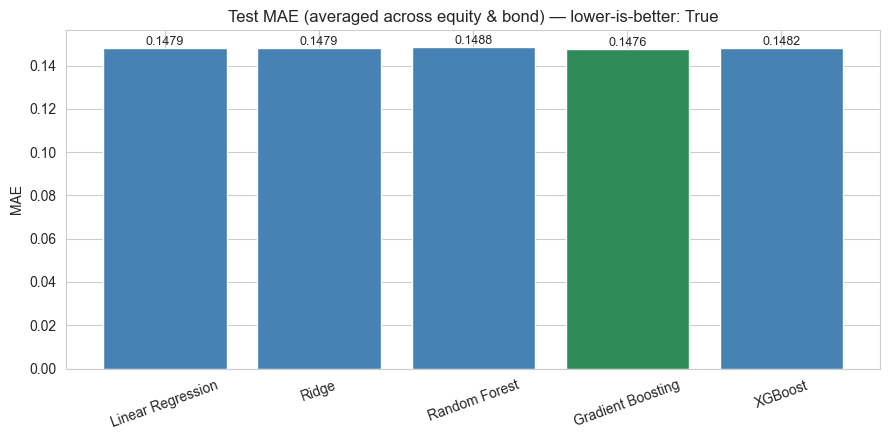

In [39]:
# Bar chart of the chosen metric, averaged across both targets.
fig, ax = plt.subplots(figsize=(9, 4.5))
scores = comparison[rank_col].astype(float)
colors = ['steelblue'] * len(scores)
# Highlight the winner.
best_idx = scores.idxmin() if LOWER_IS_BETTER[EVAL_METRIC] else scores.idxmax()
colors[list(scores.index).index(best_idx)] = 'seagreen'

bars = ax.bar(scores.index, scores.values, color=colors)
ax.set_title(f'Test {EVAL_METRIC.upper()} (averaged across equity & bond) — lower-is-better: {LOWER_IS_BETTER[EVAL_METRIC]}')
ax.set_ylabel(EVAL_METRIC.upper())
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, scores.values):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Final model selection

The winner is chosen by `EVAL_METRIC` averaged across both targets. Change `EVAL_METRIC` in section 3 and re-run — the winner may change. That's the whole point of having the knob: different metrics reward different behaviour, and a model that wins on MAE may lose on RMSE if it has one or two huge misses.

In [40]:
scores = {name: r['test_score'] for name, r in results.items()}
winner_name = (min if LOWER_IS_BETTER[EVAL_METRIC] else max)(scores, key=scores.get)
winner = results[winner_name]

print(f'Optimising for:  {EVAL_METRIC}  (lower better: {LOWER_IS_BETTER[EVAL_METRIC]})')
print(f'WINNER:          {winner_name}')
print(f'  Test {EVAL_METRIC} (avg): {winner["test_score"]:.4f}')
print(f'  Best params:        {winner["best_params"]}')
for t in TARGETS:
    print(f'  {t}: '
          + '  '.join(f'{m}={winner["test_per"][t][m]:.4f}' for m in ['mae','mape','rmse','r2']))

Optimising for:  mae  (lower better: True)
WINNER:          Gradient Boosting
  Test mae (avg): 0.1476
  Best params:        {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100}
  equity_pct: mae=0.1477  mape=0.2972  rmse=0.1759  r2=0.0624
  bond_pct: mae=0.1476  mape=1.3701  rmse=0.1756  r2=0.0673


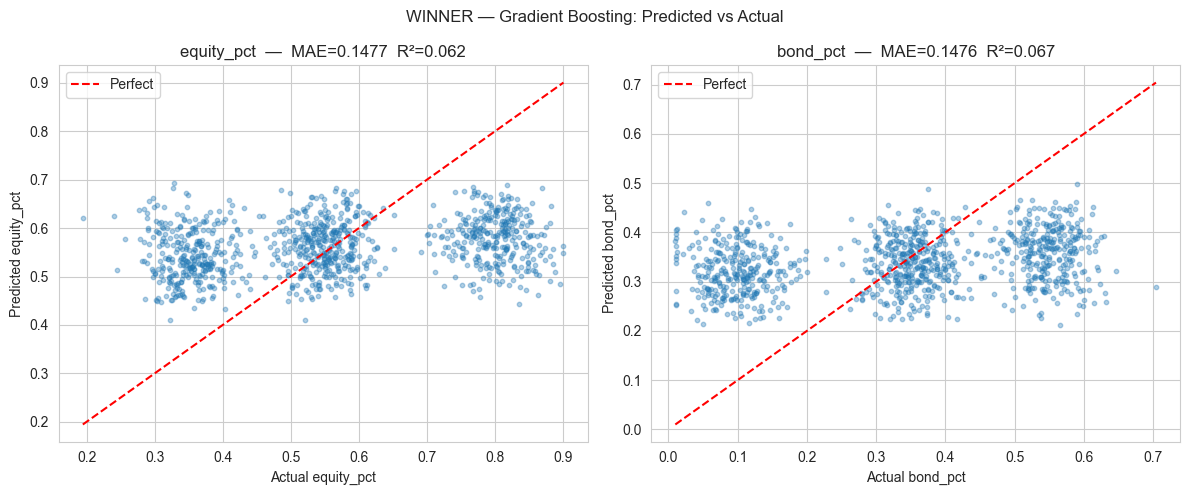

In [41]:
# Predicted-vs-actual scatter — one panel per target.
# Points on the red dashed line are perfect predictions.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, i, col in zip(axes, [0, 1], TARGETS):
    yt = y_test[col].values
    yp = winner['test_pred'][:, i]
    ax.scatter(yt, yp, alpha=0.35, s=10)
    mn, mx = yt.min(), yt.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel(f'Actual {col}')
    ax.set_ylabel(f'Predicted {col}')
    ax.set_title(f'{col}  —  MAE={winner["test_per"][col]["mae"]:.4f}  R²={winner["test_per"][col]["r2"]:.3f}')
    ax.legend()
fig.suptitle(f'WINNER — {winner_name}: Predicted vs Actual')
plt.tight_layout()
plt.show()

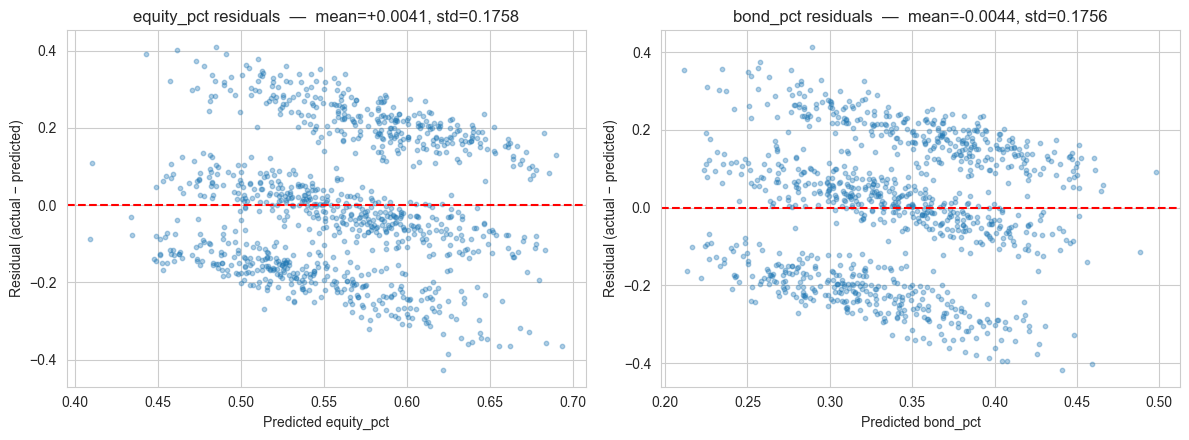

In [42]:
# Residual plots — actual minus predicted, against predicted.
# Look for: centred on 0, no funnel shape, no curve.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, i, col in zip(axes, [0, 1], TARGETS):
    yt = y_test[col].values
    yp = winner['test_pred'][:, i]
    residuals = yt - yp
    ax.scatter(yp, residuals, alpha=0.35, s=10)
    ax.axhline(0, ls='--', color='red', lw=1.5)
    ax.set_xlabel(f'Predicted {col}')
    ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title(f'{col} residuals  —  mean={residuals.mean():+.4f}, std={residuals.std():.4f}')
plt.tight_layout()
plt.show()

### Feature importance

Pulled from the Random Forest because it always exposes `feature_importances_` regardless of which model won. Linear / Ridge use coefficients (sign-dependent), XGBoost has its own scheme — we stick with RF for a clean, comparable view.

For a `MultiOutputRegressor`, each underlying estimator has its own importances. We average them across the two targets so the bar chart reflects "how important is this feature for predicting allocation overall".

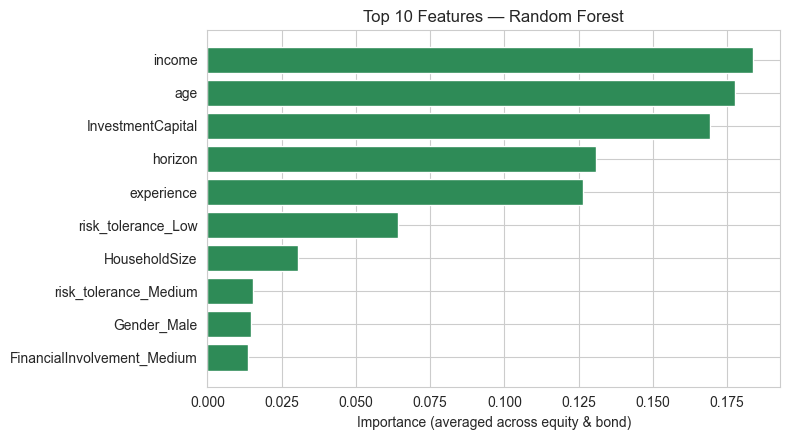

In [43]:
rf_wrapper = results['Random Forest']['model']
# MultiOutputRegressor stores one fitted estimator per target in .estimators_
imp_per_target = np.stack([est.feature_importances_ for est in rf_wrapper.estimators_])
imp_avg = imp_per_target.mean(axis=0)

fi = (pd.DataFrame({'feature': X_train.columns, 'importance': imp_avg})
        .sort_values('importance', ascending=False)
        .head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='seagreen')
ax.set_xlabel('Importance (averaged across equity & bond)')
ax.set_title('Top 10 Features — Random Forest')
plt.tight_layout()
plt.show()

## 11. Experiment area

Each prompt below is **one variable change** in section 3, then re-run all cells.

1. **Swap the metric.** Set `EVAL_METRIC = 'mae'` then `'rmse'` then `'r2'`. Does the winner change? Are the rankings consistent?
2. **Try MAPE — carefully.** Set `EVAL_METRIC = 'mape'`. Compare MAPE for `equity_pct` vs `bond_pct` in the comparison table — the bond MAPE will be much larger because some `bond_pct` values are near 0. This is the textbook MAPE failure mode.
3. **Turn off Grid Search.** Set `RUN_GRID_SEARCH = False` — every model runs on defaults. How much does tuning actually buy you?
4. **Constrain RF.** In `PARAM_GRIDS['Random Forest']`, set `estimator__max_depth: [3, 5]`. Does the RF underfit?
5. **Higher CV.** Set `CV_FOLDS = 10`. Slower, but variance of the CV score drops. Does the winner change?
6. **Compare to a dumb baseline.** In a scratch cell below, predict the **training mean** for every test row, then compute MAE / R². That's the floor any useful model must beat.
7. **Penalise the sum.** Allocations should roughly satisfy `equity + bond ≤ 1`. In a scratch cell, plot `equity_pred + bond_pred` against `equity_actual + bond_actual` for the winner — does the model respect that constraint, or does it sometimes predict sums > 1?

Use the empty cells below to try things out without scrolling back up.

In [44]:
# Scratch cell — try things here


In [45]:
# Scratch cell — try things here
